Firstly, create a GameNode class without alfa-beta pruning

In [20]:
from dataclasses import dataclass, field
from math import inf
from checkers.state import GameState
import random
from checkers.node import GameNode
from checkers import MiniMaxGameBot
from typing import override
import time
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

In [17]:
@dataclass
class GameNodeNoAlphaBeta(GameNode):
    state: "GameState"
    node_depth: int
    children: list["GameNode"] | None = field(default=None)

    def __hash__(self) -> int:
        return self.state.__hash__()

    def __eq__(self, other: object):
        if not isinstance(other, GameNode):
            return False
        return self.state == other.state
    
    def __str__(self) -> str:
        return self.state.__str__()

    def init_children(self) -> None:
        if self.children is None:
            self.children = [
                GameNode(state, self.node_depth + 1)
                for state in self.state.next_states()
            ]
            
            random.shuffle(self.children)

    @override
    def best_minimax(
        self, maximizing_player: bool, tree_depth: int) -> tuple[float, "GameNode | None"]:
        if abs(self.state.score) == inf:

            if self.state.score > 0:
                return 100_000 - self.node_depth, None
            else: 
                return -100_000 + self.node_depth, None

        if self.node_depth >= tree_depth:
            return self.state.score, None
        
        self.init_children()

        if not self.children:
            return self.state.score, None

        best_child = self.children[0]
        
        if maximizing_player:
            best_score = -inf
            for child in self.children:
                score, _ = child.best_minimax(not maximizing_player, tree_depth)
                if best_score < score:
                    best_score = score
                    best_child = child
                #if best_score >= beta:
                #    break
                #alpha = max(alpha, best_score)
            return best_score, best_child
        else:
            best_score = inf
            for child in self.children:
                score, _= child.best_minimax(not maximizing_player, tree_depth)
                if best_score > score:
                    best_score = score
                    best_child = child
                #if best_score <= alpha:
                #    break
                #beta = min(beta, best_score)
            return best_score, best_child

In [24]:
times_alpha = []
times_omega = []
depths = [i for i in range (2,6)]
for i in depths:
    bot_alfa = MiniMaxGameBot(GameNode(GameState(), 0), i) # with alpha-beta
    bot_omega = MiniMaxGameBot(GameNodeNoAlphaBeta(GameState(), 0), i) # without
    time_alpha = 0
    time_omega = 0

    time_a_start = time.perf_counter()
    child_state_1 = bot_alfa.minimax_move(True, None)
    time_a_end = time.perf_counter()
    time_alpha += time_a_end - time_a_start
    
    while True:
        time_o_start = time.perf_counter()
        child_state_2 = bot_omega.minimax_move(False, child_state_1)
        time_o_end = time.perf_counter()
        time_omega += time_o_end - time_o_start

        if not child_state_2:
            break
        #print(str(child_state_2))
        time_a_start = time.perf_counter()
        child_state_1 = bot_alfa.minimax_move(False, child_state_2)
        time_a_end = time.perf_counter()
        time_alpha += time_a_end - time_a_start
        
        if not child_state_1:
            break
        #print(str(child_state_1))
        
        if abs(child_state_1.score) == inf or abs(child_state_2.score) == inf:
            break

    times_alpha.append(time_alpha)
    times_omega.append(time_omega)
print(f"{times_alpha}\n{times_omega}")

[1.5498373469781654, 0.37495426700479584, 1.3225235909994808, 10.515363760014225]
[1.2568112999924779, 0.48119746400516306, 1.0132587329935632, 14.823630579991004]


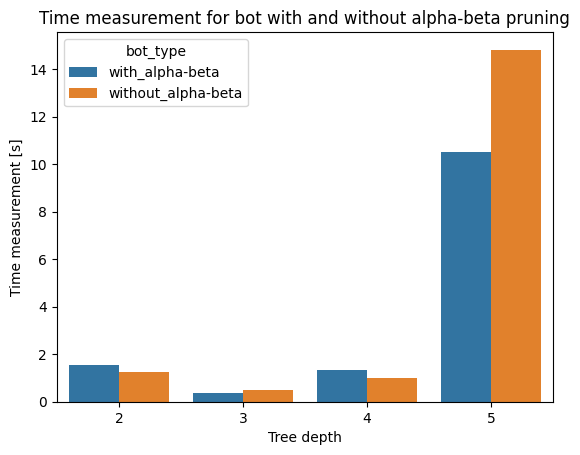

In [25]:
data = {
    'depth' : depths,
    'with_alpha-beta' : times_alpha,
    'without_alpha-beta' : times_omega
}

df = pd.DataFrame(data)
df_long = df.melt(
    id_vars='depth', value_vars=['with_alpha-beta', 'without_alpha-beta'], var_name='bot_type', value_name='time_measurement'
)

sns.barplot(data=df_long, x='depth', y='time_measurement', hue='bot_type')
plt.title('Time measurement for bot with and without alpha-beta pruning')
plt.xlabel('Tree depth')
plt.ylabel('Time measurement [s]')
plt.show()